# Upstream Prevalence and Wastewater Fits


In [6]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append("..")

from plotting_tools import * 


def detect_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "analysis").exists() and (candidate / "preprocessing").exists():
            return candidate
    return start


ROOT_DIR = detect_repo_root(Path.cwd())

# Required: directory with 0_output_v4.h5 and 1_output_v4.h5 .. 100_output_v4.h5
SIMULATION_DIR = Path("/media/iru-mls/My Book/pop8_results_2026/raw/memilio_demonstrator")

WASTEWATER_CSV = ROOT_DIR / "preprocessing/preprocessed_data/pop8/substances/decay_Nieselregen_demonstrator_output.csv"
OUTPUT_PATH = ROOT_DIR / "analysis/plots/Supplement/upstream_prevalence_wastewater.png"
PLOT_VARIABLE = "COV19"

STATION_IDS = [2, 12, 16]
STATION_TITLES = {
    2: "Station 2 (upstream)",
    12: "Station 12 (midstream)",
    16: "Station 16 (downstream)",
}


In [4]:
upstream_1 = ["83", "84", "85"]
upstream_2 = ["102", "103"]
upstream_3 = [upstream_1, upstream_2, "86", "87"]
upstream_4 = [
    upstream_3,
    "88",
    "89",
    "90",
    "91",
    "92",
    "93",
    "94",
    "95",
    "96",
    "97",
    "98",
    "99",
    "100",
    "101",
]
upstream_5 = [
    "111",
    "112",
    "113",
    "114",
    "115",
    "116",
    "117",
    "118",
    "119",
    "120",
    "121",
    "122",
    "123",
    "124",
    "125",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
]
upstream_6 = [
    "33",
    "34",
    "35",
    "36",
    "37",
    "38",
    "39",
    "104",
    "105",
    "106",
    "107",
    "108",
    "109",
    "110",
]
upstream_7 = [upstream_4, upstream_5, upstream_6, "7", "8", "9", "10"]
upstream_8 = [upstream_7, "11", "12", "13", "14"]
upstream_9 = ["33", "34", "35", "36", "37", "38", "39"]
upstream_10 = [upstream_9, "40", "41", "42", "43"]
upstream_11 = [upstream_10, "79", "80", "81", "82"]
upstream_12 = [upstream_8, upstream_11, "15", "16", "17", "18"]
upstream_13 = ["70", "72", "74", "75", "76", "77", "78"]
upstream_14 = [
    upstream_12,
    "19",
    "20",
    "21",
    "22",
    "23",
    "24",
    "25",
    "26",
    "27",
    "28",
]
upstream_15 = [
    upstream_10,
    "44",
    "45",
    "46",
    "47",
    "48",
    "49",
    "50",
    "51",
    "52",
    "53",
    "54",
    "55",
    "56",
    "57",
    "58",
    "59",
    "60",
    "61",
    "62",
    "63",
    "64",
    "66",
    "68",
    "31",
]
upstream_16 = [upstream_13, upstream_14, upstream_15, "29", "30", "32", "69", "67", "65"]

UPSTREAMS = {
    "1": upstream_1,
    "2": upstream_2,
    "3": upstream_3,
    "4": upstream_4,
    "5": upstream_5,
    "6": upstream_6,
    "7": upstream_7,
    "8": upstream_8,
    "9": upstream_9,
    "10": upstream_10,
    "11": upstream_11,
    "12": upstream_12,
    "13": upstream_13,
    "14": upstream_14,
    "15": upstream_15,
    "16": upstream_16,
}


def flatten(items):
    if isinstance(items, list):
        out = []
        for item in items:
            out.extend(flatten(item))
        return out
    return [str(items)]


def compute_upstream_metrics(h5_file, station_ids):
    station_keys = [str(s) for s in station_ids]
    flat_upstreams = {station: flatten(UPSTREAMS[station]) for station in station_keys}
    flat_upstreams = {k: list(dict.fromkeys(v)) for k, v in flat_upstreams.items()}

    with h5py.File(h5_file, "r") as f:
        times = f["data"]["transm_recovery_tp"][:]
        locs = f["data"]["loc_ids"][:].astype(np.int32)

    starts = times[:, 0]
    ends = times[:, 1]
    n_timepoints = locs.shape[1]
    time_idx = np.arange(n_timepoints)

    is_active = (
        (starts[:, None] != 100000.0)
        & (ends[:, None] != 100000.0)
        & (time_idx[None, :] >= starts[:, None])
        & (time_idx[None, :] < ends[:, None])
    )

    max_loc = int(locs.max())
    total_by_loc = np.zeros((max_loc + 1, n_timepoints), dtype=np.int32)
    infected_by_loc = np.zeros((max_loc + 1, n_timepoints), dtype=np.int32)
    infection_age_sum_by_loc = np.zeros((max_loc + 1, n_timepoints), dtype=np.float64)

    for t in range(n_timepoints):
        loc_t = locs[:, t]
        total_by_loc[:, t] = np.bincount(loc_t, minlength=max_loc + 1)

        active_t = is_active[:, t]
        if np.any(active_t):
            infected_locs = loc_t[active_t]
            infected_by_loc[:, t] = np.bincount(infected_locs, minlength=max_loc + 1)

            infection_ages = t - starts[active_t]
            infection_age_sum_by_loc[:, t] = np.bincount(
                infected_locs,
                weights=infection_ages,
                minlength=max_loc + 1,
            )

    prevalence = {}
    upstream_agents = {}
    mean_time_since_transmission_days = {}

    for station in station_keys:
        station_locs = np.array(flat_upstreams[station], dtype=int)
        station_locs = station_locs[(station_locs >= 0) & (station_locs <= max_loc)]

        if station_locs.size == 0:
            prevalence[station] = np.full(n_timepoints, np.nan, dtype=float)
            upstream_agents[station] = np.zeros(n_timepoints, dtype=float)
            mean_time_since_transmission_days[station] = np.full(n_timepoints, np.nan, dtype=float)
            continue

        total = total_by_loc[station_locs].sum(axis=0)
        infected = infected_by_loc[station_locs].sum(axis=0)
        age_sum = infection_age_sum_by_loc[station_locs].sum(axis=0)

        upstream_agents[station] = total.astype(float)
        prevalence[station] = np.divide(
            infected,
            total,
            out=np.full_like(infected, np.nan, dtype=float),
            where=total > 0,
        )
        mean_time_since_transmission_days[station] = np.divide(
            age_sum,
            infected,
            out=np.full_like(age_sum, np.nan, dtype=float),
            where=infected > 0,
        ) / 24.0

    simulation_day = np.arange(n_timepoints) / 24.0
    return simulation_day, prevalence, upstream_agents, mean_time_since_transmission_days


def summarize_ensemble(values):
    return {
        "q05": np.nanpercentile(values, 5, axis=0),
        "q25": np.nanpercentile(values, 25, axis=0),
        "q50": np.nanpercentile(values, 50, axis=0),
        "q75": np.nanpercentile(values, 75, axis=0),
        "q95": np.nanpercentile(values, 95, axis=0),
    }


def load_wastewater_summary(csv_path, station_ids, plot_variable):
    chunks = []
    usecols = ["time_in_minutes", "value", "manhole", "simulation_id", "variable"]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=2_000_000):
        chunk = chunk.loc[chunk["variable"] == plot_variable].copy()
        if chunk.empty:
            continue

        chunk["manhole"] = pd.to_numeric(chunk["manhole"], errors="coerce")
        chunk = chunk.dropna(subset=["manhole"]).copy()
        chunk["manhole"] = chunk["manhole"].astype(int)

        chunk = chunk.loc[
            chunk["manhole"].isin(station_ids)
            & chunk["simulation_id"].between(0, 100)
        ].copy()
        if chunk.empty:
            continue

        chunks.append(chunk)

    if not chunks:
        raise ValueError("No wastewater rows found for the requested stations/variable.")

    df = pd.concat(chunks, ignore_index=True)

    fitting_summary = (
        df.loc[df["simulation_id"].between(1, 100)]
        .groupby(["manhole", "time_in_minutes"])["value"]
        .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
        .unstack(level=-1)
        .rename(columns={0.05: "q05", 0.25: "q25", 0.50: "q50", 0.75: "q75", 0.95: "q95"})
        .reset_index()
    )

    ground_truth = df.loc[df["simulation_id"] == 0, ["manhole", "time_in_minutes", "value"]].rename(
        columns={"value": "ground_truth"}
    )

    plot_df = (
        ground_truth.merge(fitting_summary, on=["manhole", "time_in_minutes"], how="inner")
        .sort_values(["manhole", "time_in_minutes"])
        .copy()
    )
    plot_df["simulation_day"] = plot_df["time_in_minutes"] / (24.0 * 60.0)
    return plot_df


def _plot_interval_panel(ax, x, summary, y_label=None, title=None, show_legend=False):
    ax.fill_between(x, summary["q05"], summary["q95"], color=blue, alpha=0.20, label="90% interval")
    ax.fill_between(x, summary["q25"], summary["q75"], color=blue, alpha=0.35, label="50% interval")
    ax.plot(x, summary["q50"], color=blue, linewidth=2.0, label="Median fit")
    ax.plot(x, summary["ground_truth"], color=red, linewidth=1.6, label="Ground truth")

    if title is not None:
        ax.set_title(title)
    if y_label is not None:
        ax.set_ylabel(y_label)

    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(loc="upper left", frameon=False)



def build_combined_plot(
    prevalence_day,
    prevalence_summary,
    wastewater_df,
    upstream_agents_summary,
    infection_age_summary,
    station_ids,
    output_path,
):
    fig, axes = plt.subplots(3, 3, figsize=(16.6, 9), sharex=True)

    for col, station in enumerate(station_ids):
        station_key = str(station)
        title = STATION_TITLES.get(station, f"Station {station}")

        _plot_interval_panel(
            axes[0, col],
            prevalence_day,
            prevalence_summary[station_key],
            y_label="Prevalence" if col == 0 else None,
            title=title,
            show_legend=(col == 0),
        )

        station_df = wastewater_df.loc[wastewater_df["manhole"] == station]
        if station_df.empty:
            raise ValueError(f"No wastewater data available for station {station}.")

        ww_mask = station_df["simulation_day"] > 0.08
        ww_df = station_df.loc[ww_mask]
        wastewater_summary = {
            "q05": ww_df["q05"].to_numpy(),
            "q25": ww_df["q25"].to_numpy(),
            "q50": ww_df["q50"].to_numpy(),
            "q75": ww_df["q75"].to_numpy(),
            "q95": ww_df["q95"].to_numpy(),
            "ground_truth": ww_df["ground_truth"].to_numpy(),
        }
        _plot_interval_panel(
            axes[1, col],
            ww_df["simulation_day"].to_numpy(),
            wastewater_summary,
            y_label="Virus levels [copies/l]" if col == 0 else None,
            show_legend=False,
        )

        """
        _plot_interval_panel(
            axes[2, col],
            prevalence_day,
            upstream_agents_summary[station_key],
            y_label="Upstream agents [#]" if col == 0 else None,
            show_legend=False,
        )
        """

        _plot_interval_panel(
            axes[2, col],
            prevalence_day,
            infection_age_summary[station_key],
            y_label="Avg. time since\ntransmission [days]" if col == 0 else None,
            show_legend=False,
        )

        axes[2, col].set_xlabel("Simulation day")

    for ax in axes.flat:
        ax.set_xlim(0, 14)

    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


/home/iru-mls/Documents/repositories/INSIDeMunich/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


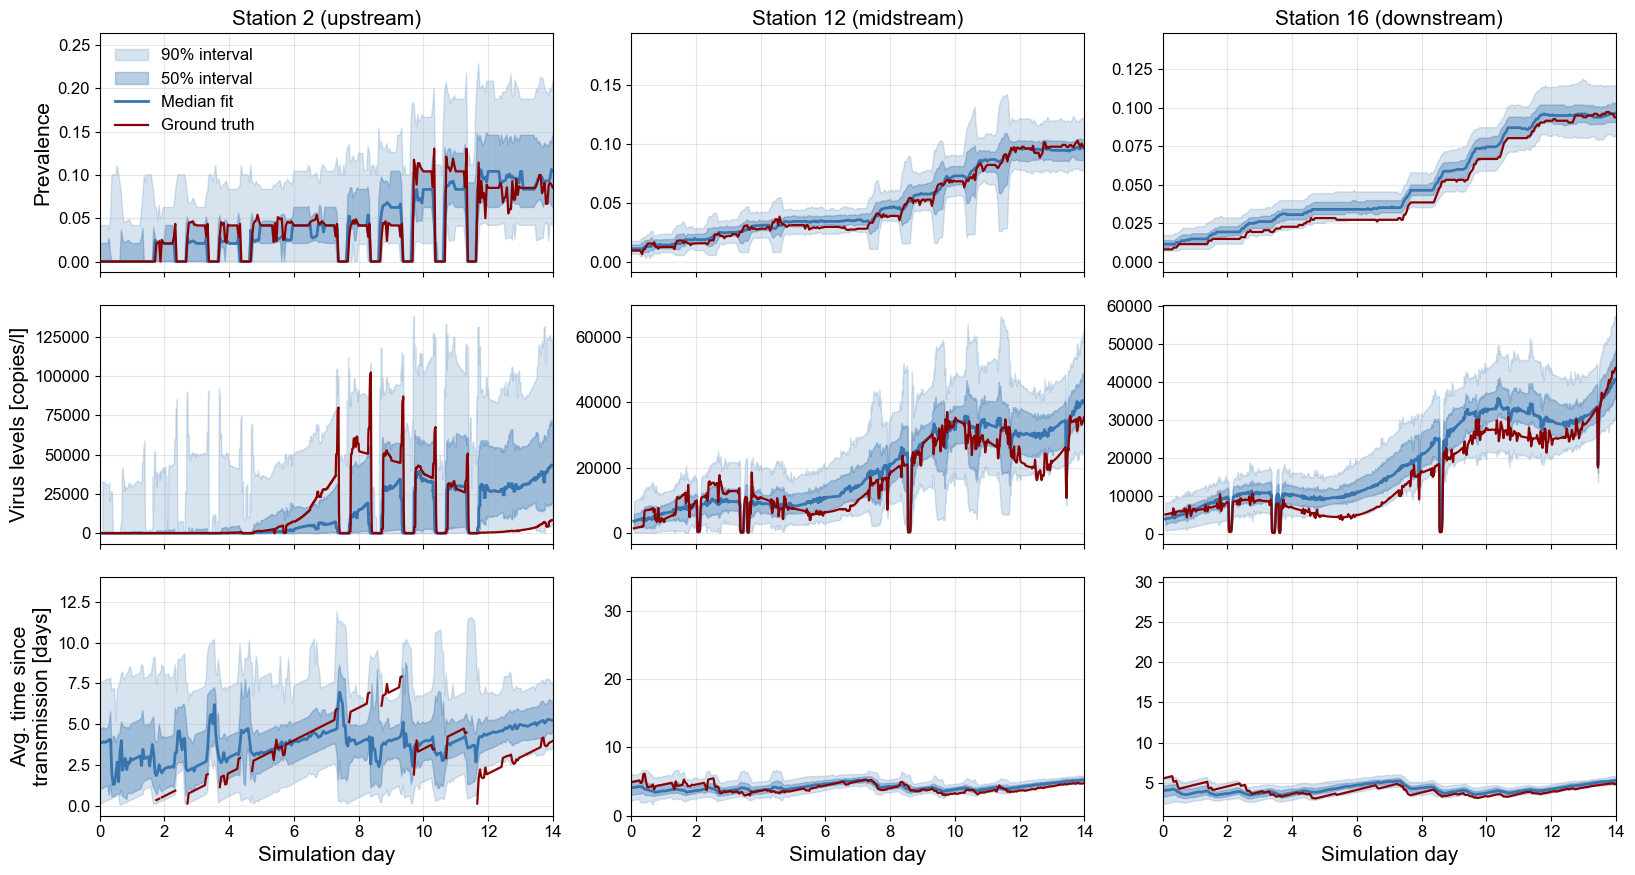

Saved: /home/iru-mls/Documents/repositories/INSIDeMunich/analysis/plots/Supplement/upstream_prevalence_wastewater.png


In [7]:
if not SIMULATION_DIR.exists():
    raise FileNotFoundError(
        f"Set SIMULATION_DIR to the folder containing 0_output_v4.h5 and 1..100_output_v4.h5. Current value: {SIMULATION_DIR}"
    )

station_keys = [str(s) for s in STATION_IDS]
prevalence_per_station = {station: [] for station in station_keys}
upstream_agents_per_station = {station: [] for station in station_keys}
infection_age_per_station = {station: [] for station in station_keys}
prevalence_day = None

for sim_id in range(1, 101):
    sim_path = SIMULATION_DIR / f"{sim_id}_output_v4.h5"
    if not sim_path.exists():
        raise FileNotFoundError(f"Missing simulation file: {sim_path}")

    sim_day, sim_prevalence, sim_upstream_agents, sim_infection_age = compute_upstream_metrics(
        sim_path, STATION_IDS
    )
    if prevalence_day is None:
        prevalence_day = sim_day
    elif len(prevalence_day) != len(sim_day):
        raise ValueError(
            f"Simulation day axis mismatch in {sim_path.name}: {len(sim_day)} vs expected {len(prevalence_day)}."
        )

    for station in station_keys:
        prevalence_per_station[station].append(sim_prevalence[station])
        upstream_agents_per_station[station].append(sim_upstream_agents[station])
        infection_age_per_station[station].append(sim_infection_age[station])

ground_truth_path = SIMULATION_DIR / "0_output_v4.h5"
if not ground_truth_path.exists():
    raise FileNotFoundError(f"Missing ground truth file: {ground_truth_path}")

(
    ground_truth_day,
    ground_truth_prevalence,
    ground_truth_upstream_agents,
    ground_truth_infection_age,
) = compute_upstream_metrics(ground_truth_path, STATION_IDS)

if len(prevalence_day) != len(ground_truth_day):
    raise ValueError("Simulation and ground-truth prevalence time axes do not match.")

prevalence_summary = {}
upstream_agents_summary = {}
infection_age_summary = {}
for station in station_keys:
    prevalence_stats = summarize_ensemble(np.array(prevalence_per_station[station]))
    prevalence_stats["ground_truth"] = ground_truth_prevalence[station]
    prevalence_summary[station] = prevalence_stats

    upstream_agents_stats = summarize_ensemble(np.array(upstream_agents_per_station[station]))
    upstream_agents_stats["ground_truth"] = ground_truth_upstream_agents[station]
    upstream_agents_summary[station] = upstream_agents_stats

    infection_age_stats = summarize_ensemble(np.array(infection_age_per_station[station]))
    infection_age_stats["ground_truth"] = ground_truth_infection_age[station]
    infection_age_summary[station] = infection_age_stats

wastewater_df = load_wastewater_summary(
    csv_path=WASTEWATER_CSV,
    station_ids=STATION_IDS,
    plot_variable=PLOT_VARIABLE,
)

build_combined_plot(
    prevalence_day=prevalence_day,
    prevalence_summary=prevalence_summary,
    wastewater_df=wastewater_df,
    upstream_agents_summary=upstream_agents_summary,
    infection_age_summary=infection_age_summary,
    station_ids=STATION_IDS,
    output_path=OUTPUT_PATH,
)

print(f"Saved: {OUTPUT_PATH}")
